In [1]:
from glob import glob

for g in glob("../data/*.pdf"):
    print(g)

../data\2040_seoul_plan.pdf
../data\OneNYC_2050_StrategicPlan.pdf


read_pdf_and_split_text 함수 만들기


In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter


def read_pdf_and_split_text(pdf_path, chunk_size=1000, chunk_overlap=100):
    """
    주어진 PDF 파일을 읽고 텍스트를 분할합니다.
    매개변수:
      pdf_path (str): PDF 파일의 경로.
      chunk_size (int, 선택적): 각 텍스트 청크의 크기, 기본값은 1000 입니다.
      chunk_overlap (int, 선택적): 청크 간의 중첩 크기. 기본값은 100 입니다.
    반환값:
      list: 분할된 텍스트 청크의 리스트.
    """

    print(f"PDF: {pdf_path} -----------------------------------")

    pdf_loader = PyPDFLoader(pdf_path)
    data_from_pdf = pdf_loader.load()

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=chunk_overlap
    )

    splits = text_splitter.split_documents(data_from_pdf)

    print(f"Number of splits: {len(splits)}\n")
    return splits

C:\Users\bny64\AppData\Local\Temp\ipykernel_10560\70338277.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [3]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from glob import glob
import os
import time
import dotenv

dotenv.load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# 임베딩 모델 선언
embedding = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-2", google_api_key=GEMINI_API_KEY
)

persist_directory = "../chroma_store"

if os.path.exists(persist_directory):
    print("Loading existing Chroma store")
    vectorstore = Chroma(
        persist_directory=persist_directory, embedding_function=embedding
    )

else:
    print("Creating new Chroma store")
    # 429 Resource Exhausted 방지를 위해 청크 단위로 나누어 인덱싱을 수행합니다.
    vectorstore = None
    batch_size = 40

    for g in glob("../data/*.pdf"):
        chunks = read_pdf_and_split_text(g)
        for i in range(0, len(chunks), batch_size):
            print(
                f"Adding documents from {i} to {min(i + batch_size, len(chunks))} for {g}..."
            )
            if vectorstore is None:
                # 첫 번째 청크로 vectorstore 초기화
                vectorstore = Chroma.from_documents(
                    documents=chunks[i : i + batch_size],
                    embedding=embedding,
                    persist_directory=persist_directory,
                )
            else:
                vectorstore.add_documents(documents=chunks[i : i + batch_size])
            time.sleep(60)
    print("Chroma store creation completed!")

Loading existing Chroma store


In [4]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

chunks = retriever.invoke("서울 온실가스 저감 계획")

for chunk in chunks:
    print(chunk.metadata)
    print(chunk.page_content)

{'moddate': '2023-02-14T18:21:42+09:00', 'creator': 'PScript5.dll Version 5.2.2', 'page_label': '71', 'author': '', 'creationdate': '2023-02-14T11:05:36+09:00', 'title': '', 'source': '../data\\2040_seoul_plan.pdf', 'page': 70, 'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'total_pages': 272}
- 도시 기반시설 부문(건물): 무공해 빌딩 확대
- 도시 기반시설 부문(교통): 무공해 차량(ZEV) 보급 촉진
- 자원/산업 부문: 3R(줄이기, 재사용, 재활용), 플라스틱, 음식물쓰레기, HFC배출량 감소
- 기후변화 적응: 기후변화 적응 조치 강화
- 거버넌스: 기업(민간), 지자체, 주요 도시 등과 협력, 재생에너지 사업 투자 촉진
8) https://fpcj.jp/en/prlisting/tokyo_20211012/
9) https://zenbird.media/zero-emissions-tokyo-an-ambitious-climate-change-strategy/
{'page': 151, 'title': '', 'total_pages': 272, 'moddate': '2023-02-14T18:21:42+09:00', 'creationdate': '2023-02-14T11:05:36+09:00', 'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'author': '', 'source': '../data\\2040_seoul_plan.pdf', 'creator': 'PScript5.dll Version 5.2.2', 'page_label': '152'}
3. 부문별 전략계획
3.1 추진위원회 회의 결과
3.2 서울시 관련 실·국·본부 의견
{'source': '../data\\2040_seou

In [5]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal
from pydantic import BaseModel, Field


# Data model
class RouteQuery(BaseModel):
    """사용자 쿼리를 가장 관련성이 높은 데이터 소스로 라우팅합니다."""

    datasource: Literal["vectorstore", "casual_talk"] = Field(
        ...,
        description="""
    사용자 질문에 따라 casual_talk 또는 vectorstore로 라우팅합니다.
    - casual_talk: 일상 대화를 위한 데이터 소스, 사용자가 질문을 할 때 사용합니다.
    - vectorstore: 사용자 질문에 답하기 위해 RAG로 vectorstore 검색이 필요한 경우 사용합니다.
    """,
    )

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv

load_dotenv()

# 모델 정의
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite", google_api_key=os.getenv("GEMINI_API_KEY")
)


# 특정 모델을 structured output(구조화된 출력)과 함께 사용하기 위해 설정
structured_llm_router = model.with_structured_output(RouteQuery)

router_system = """
당신은 사용자의 질문을 vectorstore 또는 casual_talk으로 라우팅하는 전문가입니다.
- vectorstore에는 서울, 뉴욕의 발전계획과 관련된 문서가 포함되어 있습니다. 이 주제에 대한 질문에는 vectorstore를 사용하십시오.
- 사용자의 질문이 일상 대화와 관련된 경우 casual_talk을 사용하십시오.
"""

# 시스템 메시지와 사용자의 질문을 포함하는 프롬프트 템플릿 생성
route_prompt = ChatPromptTemplate.from_messages(
    [("system", router_system), ("human", "{question}")]
)

# 라우터 프롬프트와 구조화된 출력 모델을 결합한 객체
question_router = route_prompt | structured_llm_router

In [7]:
print(question_router.invoke({"question": "서울 온실가스 저감 계획은 무엇인가요?"}))

print(question_router.invoke({"question": "잘 지냈어?"}))

datasource='vectorstore'
datasource='casual_talk'


In [8]:
from langchain_core.prompts import PromptTemplate


class GradeDocuments(BaseModel):
    """검색된 문서가 질문과 관련성이 있는지 yes 또는 no로 평가합니다."""

    binary_score: Literal["yes", "no"] = Field(
        description="문서가 질문과 관련이 있는지 여부를 'yes' 또는 'no'로 평가합니다."
    )


structured_llm_grader = model.with_structured_output(GradeDocuments)

ChatPromptTemplate: 기존 대화내용이 이어질 경우 챗봇에서 많이 사용
PromptTemplate: 기존 대화 내용이 이어질 필요가 없는 경우


In [9]:
grader_prompt = PromptTemplate.from_template(
    """
당신은 검색된 문서가 사용자 질문과 관련이 있는지 평가하는 평가자입니다. \n
문서에 사용자 질문과 관련된 키워드 또는 의미가 포함되어 있으면, 해당 문서를 관련성이 있다고 평가하십시오. \n
엄격한 테스트가 필요하지 않습니다. 목표는 잘못된 검색 결과를 걸러내는 것입니다. \n
문서가 질문과 관련이 있는지 여부를 나타내기 위해 'yes' 또는 'no' 로 이진 점수를 부여하십시오. 

Retrieved document: \n {document} \n\n
User question: {question}
"""
)

retriever_grader = grader_prompt | structured_llm_grader
question = "서울시 자율주행 관련 계획"
documents = retriever.invoke(question)

for doc in documents:
    print("---------------")
    print(doc)

---------------
page_content='104 2. 시민참여와 미래상
부문 주요 계획과제 세부내용
교통
개인형 교통수단 활성화
전동 퀵 보드, 자전거 등 전용 도로 확보
자전거 도로 개선
공유 모빌리티 규제 완화
대중교통 편의 증진
쾌적하게 이용할 수 있는 대중교통 확충
심야버스 확충, 버스 총량제 폐지
고밀보다 충분한 교통 기반시설 마련
지하철역사 내 공간을 문화, 녹지 시설로 조성
보행친화도시 추구
골목 비우기 실천을 통한 총량 확보
보행친화도시로 개발
무 장 애  보 행 로  설 치
4대문 안 자가 차량 진입 금지
친환경 교통 정책 강화
CO2, 미세먼지 감소 위한 환경 규제
수소·전기차 충전시설 확충
차량 2부제 규제 강화
자치구별 녹색교통 개선 및 확대
노후 디젤차 서울 진입 금지
남북
협력 남북 교통 인프라 확충 고속철 포함 남북 교통 인프라 확충' metadata={'producer': 'Acrobat Distiller 9.0.0 (Windows)', 'creationdate': '2023-02-14T11:05:36+09:00', 'total_pages': 272, 'page': 114, 'moddate': '2023-02-14T18:21:42+09:00', 'source': '../data\\2040_seoul_plan.pdf', 'page_label': '115', 'author': '', 'title': '', 'creator': 'PScript5.dll Version 5.2.2'}
---------------
page_content='5만 그루의 나무를 심는 등 게이트 재개발이 포함된 계획으로,6) 파리시는 2024년에서 2030년까지의 
로드맵을 수립하여 단계적으로 전환할 예정임
- (1단계 - 2024년) 대중교통과 자율주행자동차 전용도로 조성, 속도 50km/h 제한, 화물운송차량
(3.5t 초과) 진입 금지, 소음방지 장치 개발, 대체 교통수단, 버스 네트워크 개발 등
- (2단계 - 2030년) 특정 유형의 차량 전용

In [10]:
# 가져온 청크 중 서울시 자율주행 계획과 관련된 문서만 찾아 filtered_docs에 담는다.
filtered_docs = []

for i, doc in enumerate(documents):
    print(f"Document {i + 1}:")
    is_relevant = retriever_grader.invoke(
        {"question": question, "document": doc.page_content}
    )
    print(is_relevant)
    print(doc.page_content[:200])
    print("====================\n\n")

    if is_relevant.binary_score == "yes":
        filtered_docs.append(doc)

print(f"Filtered documents: {len(filtered_docs)}")

Document 1:
binary_score='no'
104 2. 시민참여와 미래상
부문 주요 계획과제 세부내용
교통
개인형 교통수단 활성화
전동 퀵 보드, 자전거 등 전용 도로 확보
자전거 도로 개선
공유 모빌리티 규제 완화
대중교통 편의 증진
쾌적하게 이용할 수 있는 대중교통 확충
심야버스 확충, 버스 총량제 폐지
고밀보다 충분한 교통 기반시설 마련
지하철역사 내 공간을 문화, 녹지 시설로 조성
보행친화도


Document 2:
binary_score='no'
5만 그루의 나무를 심는 등 게이트 재개발이 포함된 계획으로,6) 파리시는 2024년에서 2030년까지의 
로드맵을 수립하여 단계적으로 전환할 예정임
- (1단계 - 2024년) 대중교통과 자율주행자동차 전용도로 조성, 속도 50km/h 제한, 화물운송차량
(3.5t 초과) 진입 금지, 소음방지 장치 개발, 대체 교통수단, 버스 네트워크 개발 등
- (2단


Document 3:
binary_score='no'
 스마트기술의 발달로 시민참여 방안이 확대되었으며, 한정된 시간(단기 설문조사 등)이 아닌 꾸준하게 
시민의 의견을 받고 상호소통(피드백) 방식 필요
미래 서울에 대한 다양한 예측과 정보를 제공, 시민이 주체적으로 참여할 수 있는 환경 마련
 형식적인 참여 독려가 아닌 정보제공을 통한 자발적인 참여 환경 조성이 중요함


Document 4:
binary_score='yes'
3.2 서울시 관련 실·국·본부 의견 169
❚ 회의 결과
안전총괄과의 주요 계획
 [안전도시 서울도시기본계획(2018)] 서울시 재난 및 안전관리기본법
 [안전관리계획] 연례 법정계획
 [서울도시회복력강화계획] 비법정 중기계획으로 대형 재난 및 사고 발생 시 최대한 빠르게 정상 
궤도로 복귀할 수 있도록 하자는 근본적인 철학이 담긴 광범위한 계획
2


Document 5:
binary_score='no'
4. 공간계획
4.1 서울시 관련 실·국·본부 의견
4.2 자치구 의견
4.3 공간계획 자문회의 결과


In [11]:
### Generate
# PromptTemplate을 사용해 RAG를 위한 프롬프트 생성

rag_generate_system = """
너는 사용자의 질문에 대해 주어진 context에 기반하여 답변하는 도시 계획 전문가이다.
주어진 context는 vectorstore에서 검색된 결과이다.
주어진 context를 기반으로 사용자의 question에 대해 답변하라.

===================================
question: {question}
context: {context}
"""

# PromptTemplate을 생성해 question과 context를 포매팅
rag_prompt = PromptTemplate(
    input_variables=["question", "context"], template=rag_generate_system
)

# rag chain
rag_chain = rag_prompt | model

question = "서울시 자율주행 관련 계획"

rag_chain.invoke({"question": question, "context": filtered_docs})

AIMessage(content=[{'type': 'text', 'text': '도시 계획 전문가로서 제공된 자료를 바탕으로 서울시의 자율주행 관련 계획에 대해 답변드립니다.\n\n제공된 자료(2040 서울도시기본계획 관련 회의 결과)에 따르면, 서울시는 자율주행과 관련하여 다음과 같은 인식을 가지고 있습니다.\n\n1.  **미래 통행 변화에 대한 고려 필요성**: 현재 서울시의 중장기 계획 수립 과정에서 20년 후 서울시민의 통행 행태 변화를 예측하고 반영하는 것이 다소 미흡하다는 지적이 있습니다. 특히, 자율주행차의 보급이 미래 교통 환경에 미칠 영향에 대한 고려가 부족하다는 점이 주요 과제로 언급되었습니다.\n2.  **통합적 교통 예측의 필요성**: 자율주행차 도입과 더불어 카셰어링 등 새로운 이동 수단의 변화를 감안하여, 자동차 통행량을 보다 체계적으로 중장기 예측해야 한다는 의견이 제시되었습니다.\n3.  **도시 공간 및 인프라 계획과의 연계**: 자율주행 등 기술 변화는 단순히 교통 체계뿐만 아니라 GTX를 포함한 광역 철도 및 도로망의 변화와도 밀접하게 연결되어 있습니다. 따라서 향후 인구 구조와 기술 변화를 고려한 실효성 있는 공간 계획 및 시설 투자가 이루어져야 한다는 점이 강조되고 있습니다.\n\n결론적으로, 서울시는 자율주행의 등장을 미래 도시의 중요한 변화 요소로 인식하고 있으나, 향후 20년 후의 도시 계획에 이를 더욱 구체적이고 체계적으로 반영해야 한다는 정책적 보완 과제를 안고 있는 상황입니다.', 'extras': {'signature': 'EnEKbwERTTIPE5sAGitUrzV/Brosh5X5OULZ5AEkPTbiAtguwzS/Ihvd39AGHuB2AV6wLd08iaVW5ah2oG1A0b76rXd+j9Twex5S9l7aehVtzP/QevrlTInHpOIGE3S7MrklMeVljbH2/kuM0Mg+aiRf4Q=='}}], additional_kwargs={}, response_metadata={'finish_reason':

In [12]:
from typing import List
from typing_extensions import TypedDict


class GraphState(TypedDict):
    question: str  # 사용자 질문
    generation: str  # LLM 생성 결과
    documents: List[str]  # 검색된 문서

In [13]:
def route_question(state):
    """
    사용자 질문을 vectorstore 또는 casual_talk로 라우팅합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 라우팅된 데이터 소스와 사용자 질문을 포함하는 새로운 graph state
    """
    print("-----ROUTE-----")
    question = state["question"]
    route = question_router.invoke({"question": question})

    print(f"---Routing to {route.datasource} ---")
    return route.datasource

그래프 상태 선언하기


In [21]:
def retrieve(state):
    """
    vectorstore에서 질문에 대한 문서를 검색합니다.

    Args:
        state (dict): 현재 graph state

    return:
        state (dict): 검색된 문서와 사용자 질문을 포함하는 새로운 graph state
    """
    print("-----RETRIEVE-----")
    question = state["question"]

    # Retrieve documents
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

grade_documents 노드 정의하기


In [ ]:
def grade_documents(state):
    """
    검색된 문서를 평가하여 질문과 관련성이 있는지 확인합니다.

    Args:
      state (dict): 현재 graph state

    return:
      state (dict): 관련성이 있는 문서와 사용자 질문을 포함하는 새로운 graph state
    """

    print("-----GRADE-----")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []

    for i, doc in enumerate(documents):
        is_relevant = retriever_grader.invoke(
            {"question": question, "document": doc.page_content}
        )
        if is_relevant.binary_score == "yes":
            filtered_docs.append(doc)
    return {"documents": filtered_docs, "question": question}

generate 노드 정의하기


In [16]:
def generate(state):
    """
    LLM을 사용하여 문서와 사용자 질문에 대한 답변을 생성합니다.

    Args:
      state (dict): 현재 graph state

    return:
      state (dict): LLM 생성 결과와 사용자 질문을 포함하는 새로운 graph state
    """

    print("-----GENERATE-----")
    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke({"question": question, "context": documents})
    return {"documents": documents, "question": question, "generation": generation}

casual_talk 노드 정의하기


In [17]:
def casual_talk(state):
    """
    일상 대화를 위한 답변을 생성합니다.

    Args:
      state (dict): 현재 graph state

    return:
      state (dict): 일상 대화 결과와 사용자 질문을 포함하는 새로운 graph state
    """
    print("-----CASUAL TALK-----")
    question = state["question"]
    generation = model.invoke(question)
    return {"question": question, "generation": generation}

StateGraph 객체 생성하기


In [29]:
from langgraph.graph import START, StateGraph, END

workflow = StateGraph(GraphState)  # StateGraph 객체 생성

# 노드를 정의
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("casual_talk", casual_talk)

# 그래프 엣지 정의
workflow.add_conditional_edges(
    START, route_question, {"vectorstore": "retrieve", "casual_talk": "casual_talk"}
)
workflow.add_edge("casual_talk", END)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_edge("grade_documents", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()

그래프 출력하기

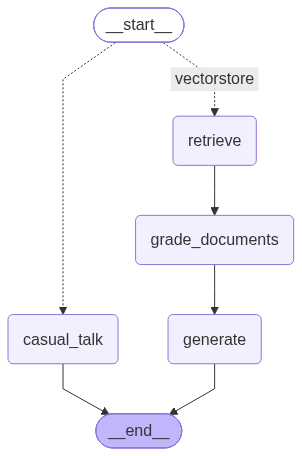

In [19]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # 실패시 통과
    pass

In [30]:
inputs = {"question": "서울시 자율주행 계획"}

app.invoke(inputs)

-----ROUTE-----
---Routing to vectorstore ---
-----RETRIEVE-----
-----GRAE-----
-----GENERATE-----


{'question': '서울시 자율주행 계획',
 'generation': AIMessage(content=[{'type': 'text', 'text': "도시 계획 전문가로서 제공된 문맥을 바탕으로 서울시 자율주행 관련 계획에 대해 답변드립니다.\n\n현재 제공된 자료(2040 서울도시기본계획 관련 의견)에 따르면, 서울시의 자율주행 계획과 관련하여 다음과 같은 시사점이 확인됩니다.\n\n1.  **미래 통행 변화에 대한 고려 필요성**: 현재의 서울시 중장기 계획에서 20년 후 서울시민의 통행 방식이 자율주행차 등으로 변화할 것에 대한 고려가 부족하다는 점이 지적되었습니다.\n2.  **중장기 예측의 필요성**: 자율주행과 같은 기술적 변화는 향후 도시 내 자동차 통행량에 영향을 미치는 요소이므로, 카셰어링 등 새로운 이동 수단의 변화를 감안한 통행량 중장기 예측이 선행되어야 한다는 의견이 제시되었습니다.\n3.  **스마트 기술 활용 방향**: 직접적인 '자율주행 도입 계획'이 구체적으로 명시되어 있지는 않으나, 향후 서울시는 재난 및 안전관리 분야에서 스마트 기술을 적극적으로 적용하여 정보화 및 자동화를 추진함으로써 안전 부문을 강화해야 한다는 방향성이 언급되어 있습니다.\n\n결론적으로, 현재의 계획 단계에서는 자율주행과 같은 미래 기술 변화를 도시 공간 계획에 어떻게 반영하고 예측할 것인지에 대한 논의와 보완이 필요한 시점으로 파악됩니다.", 'extras': {'signature': 'EnEKbwERTTIPcJ59yg7P4CCpc7SGz9uEGIR85ANIlOP1WSUq0ijUf8OOk8XJtymhQOCrPkP3fuyjqfj526RCr68qLsKAUfk1icQKjBwlAJxWery9wbFSfE2msgaBnJ5i/K24sl2PJLmjozmC0nq9TdqPLw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-li

In [31]:
inputs = {"question": "서잘 지내고 있어?"}

app.invoke(inputs)

-----ROUTE-----
---Routing to casual_talk ---
-----CASUAL TALK-----


{'question': '서잘 지내고 있어?',
 'generation': AIMessage(content=[{'type': 'text', 'text': '네, 저는 아주 잘 지내고 있어요! 물어봐 주셔서 감사합니다. 😊\n\n도움이 필요하거나 궁금한 점이 있으신가요? 아니면 그냥 이런저런 이야기를 나누고 싶으신가요? 어떤 것이든 좋아요! 당신은 어떻게 지내고 계신가요?', 'extras': {'signature': 'EnEKbwERTTIP0tRAIYT/FcNJoZ8ogEsHmpWSlyhlq2yXhtDz8IhAtQWXllhwJIaCTesE3j9t9VNdZct7oBDjIVdd8EjNomDIAAEtqQ24e0kUil3W7xXNsjHsg0vuYTqzXzJ8I2tcv5K4KR54BXBSUVjfGw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00fb6-3b3f-7042-962b-d79c1bf193d1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 64, 'total_tokens': 72, 'input_token_details': {'cache_read': 0}})}

In [33]:
inputs = {"question": "서울시의 자율주행 차량 계획은 무엇이 있나요?"}

for msg, meta in app.stream(inputs, stream_mode="messages"):
    content = msg.content
    
    # 1. content가 리스트 형태인 경우 (Gemini의 일반적인 스트리밍 반환 형태)
    if isinstance(content, list):
        for part in content:
            if isinstance(part, dict) and "text" in part:
                print(part["text"], end="")
            elif isinstance(part, str):
                print(part, end="")
                
    # 2. content가 일반 문자열인 경우
    else:
        print(content, end="")


-----ROUTE-----
{
  "datasource": "vectorstore"
}---Routing to vectorstore ---
-----RETRIEVE-----
-----GRAE-----
{
  "binary_score": "no"
}{
  "binary_score": "no"
}{
  "binary_score": "no"
}{
  "binary_score": "yes"
}{"binary_score": "no"}-----GENERATE-----
도시 계획 전문가로서 제공된 문서를 분석한 결과, 서울시의 자율주행 차량 계획과 관련하여 다음과 같이 답변드립니다.

현재 제공된 자료(2040 서울도시기본계획 관련 의견서)에 따르면, 서울시는 20년 후의 미래 여건 변화를 고려한 중장기 계획 수립의 필요성을 논의하고 있으나, **현재 단계에서 구체적인 자율주행 차량 도입 계획이나 실행 로드맵이 상세히 기술되어 있지는 않습니다.**

다만, 해당 문서에서는 다음과 같은 관점에서 자율주행 기술 도입의 중요성을 언급하고 있습니다:

* **미래 통행 변화 고려의 필요성:** 서울시의 법정 최상위 계획 수립 시, 20년 후 시민들의 통행 패턴 변화에 자율주행차가 미칠 영향을 반드시 고려해야 한다는 점이 지적되었습니다.
* **계획의 실효성 확보:** 인구 구조, 기술 변화 등을 고려하지 않은 현재의 SOC 사업이나 시설 투자 계획은 실효성이 낮을 수 있음을 언급하며, 자율주행차와 같은 기술 변화를 반영한 중장기적인 통행량 예측과 공간 계획이 수립되어야 함을 강조하고 있습니다.

결론적으로, 현재 서울시는 미래 도시 계획 수립 과정에서 자율주행차라는 새로운 기술 환경에 대한 대응 방안을 고민하고 있으며, 이를 반영한 체계적인 예측과 전략적 접근이 필요하다는 전문가적 의견이 제시된 상태라고 볼 수 있습니다.